---
To run the code please insert your file path in 4 locations: 
---
## Under point 1) three times: 
two times right below point 1)                                
and a third time a bit below point 1) includding "\NYU_50952_cc200_timeseries.csv" to run the example (its just for understanding and not necessary) 
## Under Point 4) one time:
including "abide_cc200_features_with_phenotypics.csv" . Very important as this is the final data set (you'll also have it in your path as CSV file). 


In [1]:
%pip install nilearn pandas numpy

from nilearn.datasets import fetch_abide_pcp
import numpy as np
import pandas as pd
import os
import os, itertools
from pathlib import Path
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:

data = fetch_abide_pcp(
    n_subjects=None,
    pipeline='cpac',
    band_pass_filtering=True,
    global_signal_regression=True,
    derivatives=['rois_cc200'],
    quality_checked=False
)

# data.phenotypic is a pandas DataFrame
# data.rois_cc200 is a list of ROI time-series files


[fetch_abide_pcp] Dataset found in C:\Users\Leopo\nilearn_data\ABIDE_pcp

In [18]:
phen = pd.DataFrame(data.phenotypic)  # subject-level info (SUB_ID, SITE_ID, FIQ, etc.)
roi_files = data.rois_cc200           # list of file paths: one .1D per subject
len(roi_files), phen.shape

(1035, (1035, 106))

In [6]:
phen

,i,Unnamed: 0,SUB_ID,X,subject,SITE_ID,FILE_ID,DX_GROUP,DSM_IV_TR,AGE_AT_SCAN,...,qc_notes_rater_1,qc_anat_rater_2,qc_anat_notes_rater_2,qc_func_rater_2,qc_func_notes_rater_2,qc_anat_rater_3,qc_anat_notes_rater_3,qc_func_rater_3,qc_func_notes_rater_3,SUB_IN_SMP
1,1,2,50003,2,50003,PITT,Pitt_0050003,1,1,24.45,...,NaN,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1
2,2,3,50004,3,50004,PITT,Pitt_0050004,1,1,19.09,...,NaN,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1
3,3,4,50005,4,50005,PITT,Pitt_0050005,1,1,13.73,...,NaN,OK,NaN,maybe,ic-parietal-cerebellum,OK,NaN,OK,NaN,0
4,4,5,50006,5,50006,PITT,Pitt_0050006,1,1,13.37,...,NaN,OK,NaN,maybe,ic-parietal slight,OK,NaN,OK,NaN,1
5,5,6,50007,6,50007,PITT,Pitt_0050007,1,1,17.78,...,NaN,OK,NaN,maybe,ic-cerebellum_temporal_lob,OK,NaN,OK,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,1107,1108,51583,1108,51583,SBL,SBL_0051583,1,2,35.00,...,NaN,OK,NaN,OK,ic-cerebellum-temporal_lobe,OK,NaN,OK,NaN,0
1108,1108,1109,51584,1109,51584,SBL,SBL_0051584,1,2,49.00,...,NaN,OK,NaN,maybe,vmpfc dropout,OK,NaN,OK,NaN,0
1109,1109,1110,51585,1110,51585,SBL,SBL_0051585,1,1,27.00,...,NaN,OK,NaN,maybe,ic-cerebellum-temporal_lobe,OK,NaN,OK,NaN,0
1110,1110,1111,51606,1111,51606,MAX_MUN,MaxMun_a_0051606,1,2,29.00,...,NaN,OK,NaN,maybe,ic-cerebellum,OK,NaN,OK,NaN,0


In [1]:
roi_files[2:]

## 1) Save raw ROI time series (one CSV per subject)
Each .1D file → DataFrame with columns roi_001 … roi_200.

In [19]:
out_dir = Path(r"your\file\path\here")
out_dir.mkdir(parents=True, exist_ok=True)
print(out_dir.resolve())

In [20]:
ts_dir = Path(r"your\file\path\here")
print(ts_dir.resolve())

In [21]:

# 'phen' and 'data' come from fetch_abide_pcp(...)
# phen = pd.DataFrame(data.phenotypic)
# roi_series_list = data.rois_cc200   # <-- this is a list of NumPy arrays (T x 200)

roi_series_list = data.rois_cc200
assert len(roi_series_list) == len(phen)

def save_timeseries_csv(arr, site, sub_id, n_rois_expected=200):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        arr = arr[np.newaxis, :]
    # basic sanity
    if arr.shape[1] != n_rois_expected:
        raise ValueError(f"Expected {n_rois_expected} ROIs, got {arr.shape[1]} for SUB_ID={sub_id}")
    cols = [f"roi_{i:03d}" for i in range(1, n_rois_expected+1)]
    df = pd.DataFrame(arr, columns=cols)
    out_path = ts_dir / f"{site}_{sub_id}_cc200_timeseries.csv"
    df.to_csv(out_path, index=False)
    return out_path

saved = 0
for i, arr in enumerate(roi_series_list):
    sub_id = int(phen.iloc[i]["SUB_ID"])
    site   = str(phen.iloc[i].get("SITE_ID", "NA"))
    save_timeseries_csv(arr, site, sub_id, n_rois_expected=200)
    saved += 1

print(f"Saved {saved} ROI time series CSV files to: {ts_dir}")


In [22]:
example = pd.read_csv(r"your\file\path\here\NYU_50952_cc200_timeseries.csv")

In [23]:
example

,roi_001,roi_002,roi_003,roi_004,roi_005,roi_006,roi_007,roi_008,roi_009,roi_010,...,roi_191,roi_192,roi_193,roi_194,roi_195,roi_196,roi_197,roi_198,roi_199,roi_200
0,9.897378,-33.627350,13.127982,-27.227295,5.851211,9.780756,-5.373211,2.639516,7.820141,-8.153430,...,-9.495734,27.760228,-36.018941,-25.990700,22.980530,-3.039020,-0.687924,-4.366415,-45.646008,-1.373839
1,29.906488,-7.552979,-10.156289,-25.140734,27.467839,30.342580,5.888297,3.548331,-1.448760,-4.375062,...,-11.879620,38.347706,-51.204057,-36.262713,20.001066,10.768186,17.358766,-3.360825,-89.019590,-7.023411
2,34.021646,30.440560,-34.540510,-20.816608,51.945170,37.488728,23.015877,-4.551307,-18.848445,3.734440,...,1.596344,16.300198,-25.444480,-28.338285,-4.265083,14.828203,23.454054,1.795061,-101.157325,-30.578927
3,12.888421,44.748766,-47.458383,-23.202661,67.178783,25.016867,33.610246,-20.168597,-36.523134,8.671703,...,24.511483,-24.228398,23.343820,-5.469224,-32.634231,5.515945,10.823310,-0.198524,-60.781146,-62.271802
4,-19.770530,20.611681,-45.856039,-26.374137,60.666444,6.262894,27.583199,-31.180997,-49.068405,1.346543,...,35.881853,-53.440538,50.792951,17.452214,-43.573378,-0.460893,-7.587968,-11.502668,7.667749,-72.174705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,7.291509,0.629937,-45.914012,3.005230,7.800893,-12.498274,6.499224,-9.436836,18.216664,20.852281,...,-23.639870,0.733735,-11.251333,-5.171964,-31.920396,-30.311313,-15.977392,16.296972,22.339714,-32.014601
172,9.753675,17.444615,-55.830482,5.350419,-21.623009,-5.484870,23.650567,9.275132,-2.382547,-1.220513,...,-21.368509,-9.111501,-5.930558,12.894039,-3.107192,-30.386742,3.065716,7.135046,42.106747,-15.535657
173,3.647960,26.433305,-64.399023,2.086570,-45.559930,-7.778946,28.654272,30.632390,-23.132690,-18.203422,...,-0.617463,-15.592267,32.287967,24.575339,16.942355,-17.649374,8.292345,8.357916,18.367157,-1.339113
174,-11.772698,23.153361,-59.673885,-3.265410,-39.651512,-16.815434,18.202701,35.945562,-32.251933,-15.310282,...,16.950470,-15.650541,71.420150,24.147775,17.065251,2.763550,-0.502756,12.388255,-11.161642,3.888493


In [24]:
n = 1035*200*176
print(f"pure observations at this point: {n:,}")

pure observations at this point: 36,432,000


## 2) Build and save functional connectivity features (one row per subject)

Compute Pearson correlation across ROI time series → 200×200 matrix.

Take the upper triangle (without diagonal) and Fisher z-transform it (optional but standard).

Stack all subjects into a single features CSV.

## From correlations to features

**ROI signals.** With $n=200$ CC200 ROIs and $T$ time points, each ROI has a mean time series
$\mathbf{x}_i=(x_{i1},\dots,x_{iT})^\top$.
CC200 gives spatially contiguous, functionally homogeneous ROIs for resting-state analysis. (Craddock et al., 2012)

**Pearson correlation.** For ROIs $i\neq j$,
$
r_{ij}
=\frac{\sum_{t=1}^{T}(x_{it}-\bar{x}_i)(x_{jt}-\bar{x}_j)}
{\sqrt{\sum_{t=1}^{T}(x_{it}-\bar{x}_i)^2}\;\sqrt{\sum_{t=1}^{T}(x_{jt}-\bar{x}_j)^2}},
\quad r_{ii}=1.
$
Stacking all $r_{ij}$ gives a symmetric $n\times n$ matrix $\mathbf{R}$.

**Upper triangle only.** $(\mathbf{R}$ is symmetric; the diagonal carries no between-ROI info. Keep the strict upper triangle:
$
p=\frac{n(n-1)}{2}\quad\text{unique edges (for }n=200,\;p=19{,}900\text{)}.
$
Vectorize to get a feature vector $\mathbf{r}\in\mathbb{R}^{p}$.

**Fisher $z$.** Correlations are bounded and skewed. Apply
$
z=\tfrac{1}{2}\ln\!\left(\frac{1+r}{1-r}\right)=\operatorname{arctanh}(r),
$
which maps to $\mathbb{R}$ and yields an approximately normal sampling distribution with
$\mathrm{Var}(z)\approx 1/(T_{\text{eff}}-3)$.
Average across subjects in $z$-space; clip $r$ to $[-1+\varepsilon,1-\varepsilon]$ before transforming to avoid infinities.


In [25]:
# Create a features DataFrame: one row per subject, columns = fc_... features
n_rois = 200
roi_names = [f"roi_{i:03d}" for i in range(1, n_rois+1)]

# names for the upper triangle (without diagonal)
upper_cols = []
for i in range(n_rois):
    for j in range(i+1, n_rois):
        upper_cols.append(f"fc_{roi_names[i]}__{roi_names[j]}")

def fc_upper_fisherz(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        arr = arr[np.newaxis, :]
    # correlation across ROIs
    corr = np.corrcoef(arr, rowvar=False)  # (200 x 200)
    corr = np.clip(corr, -0.999999, 0.999999)
    z = np.arctanh(corr)  # Fisher z
    iu = np.triu_indices_from(z, k=1)
    return z[iu]  # vector length = 200*199/2 = 19,900

rows = []
for i, arr in enumerate(roi_series_list):
    sub_id = int(phen.iloc[i]["SUB_ID"])
    site   = str(phen.iloc[i].get("SITE_ID", "NA"))
    vec = fc_upper_fisherz(arr)
    row = {"SUB_ID": sub_id, "SITE_ID": site}
    # attach features
    row.update({c: v for c, v in zip(upper_cols, vec)})
    rows.append(row)

features_df = pd.DataFrame(rows, columns=["SUB_ID", "SITE_ID"] + upper_cols)
feat_csv = out_dir / "abide_cc200_connectivity_features.csv"
features_df.to_csv(feat_csv, index=False)
print("Connectivity features saved to:", feat_csv)


C:\Users\Leopo\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Leopo\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Little example to understand data transformation, especially Pearson correlation

In [4]:
200*(200-1)/2

19900.0

In [44]:
 7266**2 / 2 / 964

27383.172199170123

In [39]:
1/2 * (200**2-200)

19900.0

In [51]:
(9+29-23)/3

5.0

In [52]:
(-33-7.5+11)/3

-9.833333333333334

In [53]:
(-1.37-7.02+0.36)/3

-2.676666666666667

Pearson correlation

In [55]:
((9-5)*(-33+9.83)+(29-5)*(-7.5+9.83)+(-23-5)*(11+9.83))/(np.sqrt((9-5)**2+(29-5)**2+(-23-5)**2)*np.sqrt((-33+9.83)**2+(-7.5+9.83)**2+(11+9.83)**2))

np.float64(-0.5349589752981845)

Fisher z 

In [63]:
1/2*np.log((1-0.53)/(1+0.53))

np.float64(-0.5901451598411885)

In [59]:
np.arctanh(-0.53)

np.float64(-0.5901451598411885)

In [71]:
np.arctanh(-0.9999999999999999)

np.float64(-18.714973875118524)

In [72]:
np.arctanh(0.9999999999999999)

np.float64(18.714973875118524)

## 3) Saves a joined table with phenotypics

This gives one CSV that already contains FIQ, SEX, AGE_AT_SCAN, etc., plus the connectivity features

In [26]:
keep_phen = ["SUB_ID","SITE_ID","SEX","AGE_AT_SCAN","FIQ","VIQ","PIQ","DX_GROUP"]
phen_small = phen[keep_phen].copy()

joined = phen_small.merge(features_df, on=["SUB_ID","SITE_ID"], how="inner")
joined_csv = out_dir / "abide_cc200_features_with_phenotypics.csv"
joined.to_csv(joined_csv, index=False)
print("Joined phenotypics + features saved to:", joined_csv)

## 4) Start from here without building the data frame 

In [2]:
df = pd.read_csv(r"your\file\path\here\abide_cc200_features_with_phenotypics.csv")

In [28]:
df#[:6]

,SUB_ID,SITE_ID,SEX,AGE_AT_SCAN,FIQ,VIQ,PIQ,DX_GROUP,fc_roi_001__roi_002,fc_roi_001__roi_003,...,fc_roi_196__roi_197,fc_roi_196__roi_198,fc_roi_196__roi_199,fc_roi_196__roi_200,fc_roi_197__roi_198,fc_roi_197__roi_199,fc_roi_197__roi_200,fc_roi_198__roi_199,fc_roi_198__roi_200,fc_roi_199__roi_200
0,50003,PITT,1,24.45,124.0,128.0,115.0,1,0.254256,0.138886,...,-0.061197,0.047524,-0.221457,0.153468,-0.022266,0.408322,0.030477,0.101061,0.109924,-0.279551
1,50004,PITT,1,19.09,113.0,108.0,117.0,1,0.139748,0.060216,...,-0.217972,0.064999,-0.102200,0.264136,-0.365952,0.158622,-0.165171,-0.071769,0.114758,-0.308732
2,50005,PITT,2,13.73,119.0,117.0,118.0,1,-0.261228,0.107575,...,-0.220945,0.170028,0.218101,0.010837,-0.224393,0.122561,0.140934,-0.151993,0.231814,-0.012395
3,50006,PITT,1,13.37,109.0,99.0,119.0,1,-0.397648,-0.060489,...,0.059279,-0.043634,-0.051347,-0.138007,-0.210264,-0.161598,-0.037531,0.425893,0.282573,-0.314583
4,50007,PITT,1,17.78,110.0,106.0,112.0,1,-0.234764,-0.297842,...,-0.005487,-0.149616,0.237514,0.125590,-0.284132,-0.156635,-0.117103,0.442652,-0.091180,-0.426865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1030,51583,SBL,1,35.00,95.0,105.0,84.0,1,-0.086630,-0.035811,...,-0.194794,0.106572,-0.469715,0.231539,0.070129,-0.005804,-0.105312,-0.080569,-0.093879,-0.222730
1031,51584,SBL,1,49.00,-9999.0,133.0,135.0,1,0.124047,0.074379,...,-0.077477,0.064686,-0.167777,0.266218,-0.197266,-0.024636,0.252992,-0.106084,-0.083630,0.091470
1032,51585,SBL,1,27.00,96.0,99.0,106.0,1,-0.221459,0.025854,...,-0.376487,0.164526,-0.053293,0.682663,-0.006753,-0.448059,-0.067678,0.214198,-0.107426,-0.190546
1033,51606,MAX_MUN,2,29.00,118.0,NaN,NaN,1,-0.380491,-0.369749,...,-0.056370,-0.102976,-0.073801,-0.137963,-0.193343,-0.274157,0.427244,0.145671,0.165940,-0.180665


In [4]:
print(f"{(19900+8)*1035:,}")

20,604,780


In [29]:
dx = df["DX_GROUP"].map({1: "ASD", 2: "Control"})
dx_counts = dx.value_counts(dropna=True)
dx_pct = (dx_counts / dx_counts.sum() * 100).round(1)
print(dx_counts); print(dx_pct)

DX_GROUP
Control    530
ASD        505
Name: count, dtype: int64
DX_GROUP
Control    51.2
ASD        48.8
Name: count, dtype: float64


Visualizing upper triangle of pearson correlations, comparing autistic vs. non-autistic subjects:

Detected ROIs: 200  | #edges: 19900


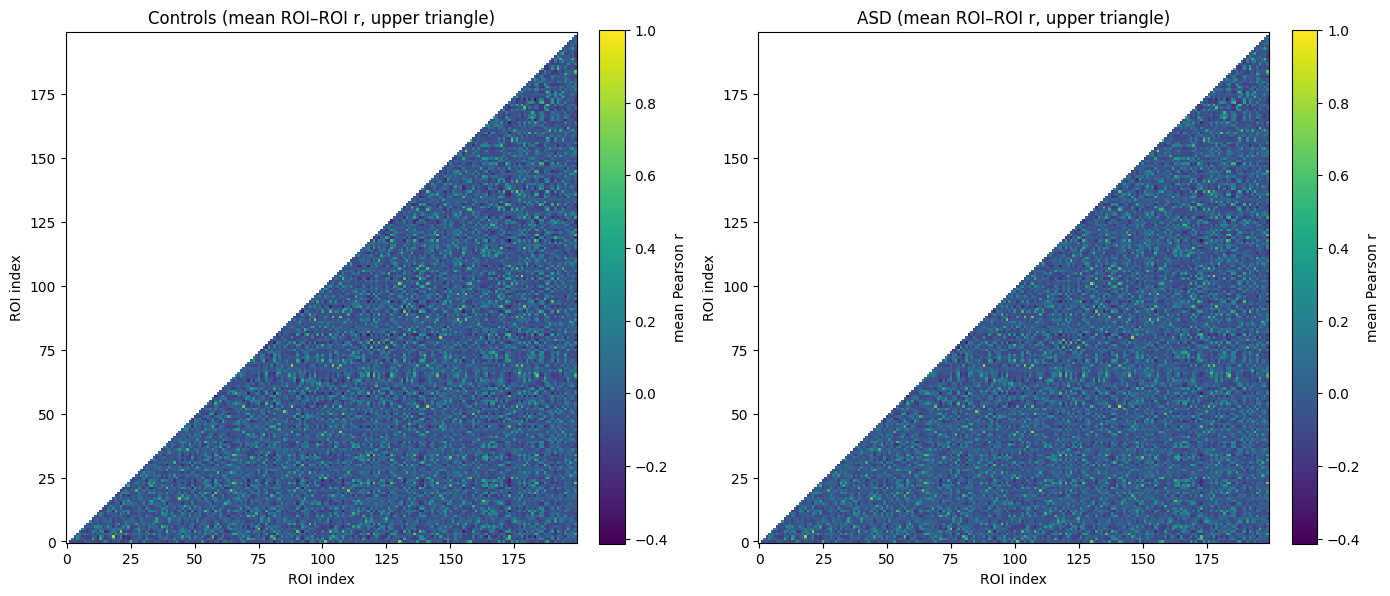

In [30]:
# --- 0) Prepare: find the fc_ columns and infer number of ROIs ---
fc_cols = [c for c in df.columns if c.startswith("fc_")]
assert len(fc_cols) > 0, "No fc_ columns found."

# parse 'fc_roi_001__roi_002' -> (1,2)
pair_idx = []
for c in fc_cols:
    i, j = map(int, re.findall(r'roi_(\d+).*roi_(\d+)', c)[0])
    pair_idx.append((i, j))

n_rois = max(max(i, j) for i, j in pair_idx)  # should be 200
print("Detected ROIs:", n_rois, " | #edges:", len(fc_cols))

# precompute upper-triangle index map (0-based indices for a matrix fill)
# we'll map ROI labels 1..n to matrix indices 0..n-1
ij_0based = np.array([(i-1, j-1) for (i, j) in pair_idx], dtype=int)

# --- 1) helper: mean correlation matrix for a group (average in z-space, then tanh) ---
def mean_corr_matrix(df_group):
    """
    df_group: dataframe filtered to a class (ASD/Control).
    Returns an (n_rois x n_rois) symmetric matrix with diag=1 and upper triangle filled
    with mean correlations (tanh of mean Fisher-z).
    """
    # mean Fisher-z per edge (skip NaN)
    z_mean = df_group[fc_cols].mean(axis=0, skipna=True).to_numpy(dtype=float)
    r_mean = np.tanh(z_mean)  # back to Pearson r

    M = np.eye(n_rois, dtype=float)
    # fill upper triangle from r_mean using our parsed indices
    M[ij_0based[:,0], ij_0based[:,1]] = r_mean
    # mirror to lower triangle
    M = M + M.T - np.eye(n_rois)
    return M

# --- 2) build matrices for Control and ASD ---
M_ctrl = mean_corr_matrix(df[df["DX_GROUP"] == 2])
M_asd  = mean_corr_matrix(df[df["DX_GROUP"] == 1])

# --- 3) plotting: show only upper triangle for each (mask the lower) ---
def plot_upper_triangle(M, title, vmin=None, vmax=None):
    # mask lower triangle (including diagonal?) -> keep diagonal if you like; here we show only strict upper
    mask = np.tril(np.ones_like(M, dtype=bool), k=0)  # True on diag & below
    M_plot = np.ma.array(M, mask=mask)
    im = plt.imshow(M_plot, interpolation="none", origin="lower",
                    vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("ROI index")
    plt.ylabel("ROI index")
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("mean Pearson r")

# common color scale for fair comparison
vmin = min(M_ctrl[~np.isnan(M_ctrl)].min(), M_asd[~np.isnan(M_asd)].min())
vmax = max(M_ctrl[~np.isnan(M_ctrl)].max(), M_asd[~np.isnan(M_asd)].max())

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plot_upper_triangle(M_ctrl, "Controls (mean ROI–ROI r, upper triangle)", vmin, vmax)

plt.subplot(1, 2, 2)
plot_upper_triangle(M_asd, "ASD (mean ROI–ROI r, upper triangle)", vmin, vmax)

plt.tight_layout()
plt.show()


## Start Machine Learning Part

In [3]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance

In [7]:
df.isna().sum().sum()

np.int64(74697)

In [9]:
19000*1000

19000000

In [10]:
74697/19000000

0.003931421052631579

less than 1% of observations are missing

In [8]:
df.isna().sum()

SUB_ID                  0
SITE_ID                 0
SEX                     0
AGE_AT_SCAN             0
FIQ                    34
                       ..
fc_roi_197__roi_199     3
fc_roi_197__roi_200     3
fc_roi_198__roi_199    16
fc_roi_198__roi_200    16
fc_roi_199__roi_200     1
Length: 19908, dtype: int64

In [9]:
df['DX_GROUP'].isna().sum()

np.int64(0)

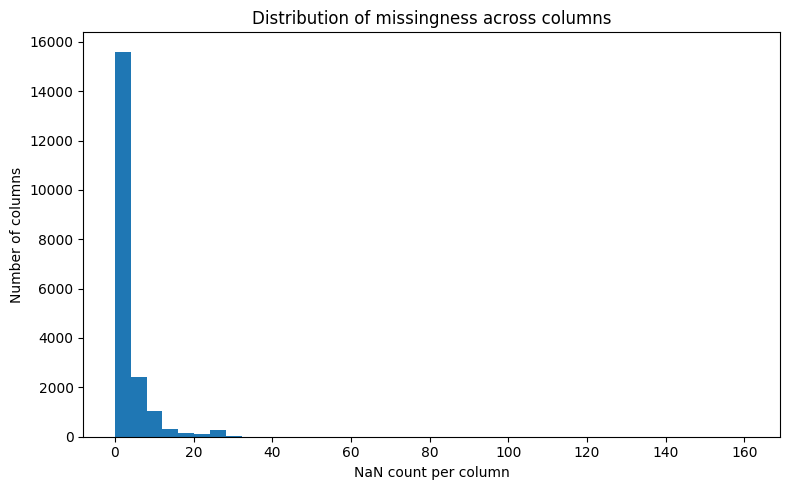

In [43]:
na_counts = df.isna().sum()
plt.figure(figsize=(8,5))
plt.hist(na_counts, bins=40)
plt.xlabel("NaN count per column")
plt.ylabel("Number of columns")
plt.title("Distribution of missingness across columns")
plt.tight_layout()
plt.show()

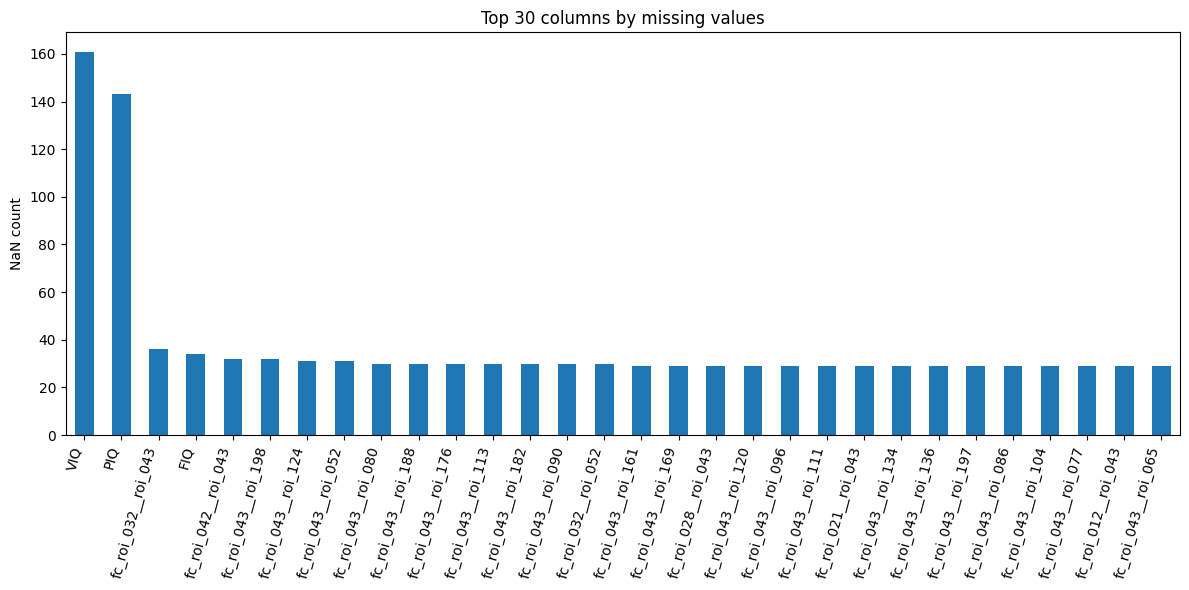

In [44]:
na_counts = df.isna().sum().sort_values(ascending=False)
top = na_counts.head(30)

plt.figure(figsize=(12,6))
top.plot(kind="bar")
plt.ylabel("NaN count")
plt.title("Top 30 columns by missing values")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [45]:
160/1000

0.16

16% of VIQ is missing

## ML preperation

In [4]:
# --- targets, groups, features ---
df = df.copy()

# diagnosis: 1=ASD, 2=Control  → make labels 'ASD'/'Control'
df["DX"] = df["DX_GROUP"].map({1: "ASD", 2: "Control"}).astype("category")

# site for grouping (avoid site leakage). SITE_ID column (one value per row/subject), like ["PITT","NYU","CALTECH",... ]
groups = df["SITE_ID"].astype(str).fillna("NA").to_numpy()

# feature columns = all functional connectivity columns
feat_cols = [c for c in df.columns if c.startswith("fc_")]
X = df[feat_cols].copy()

# median imputation for features (robust & fast)
X = X.fillna(X.median())
X = X.to_numpy(dtype=np.float32)

Y = df["DX"].to_numpy()   # labels

print(f"Rows: {len(Y)}, features: {X.shape[1]}, ASD share: {(Y=='ASD').mean():.3f}")

Rows: 1035, features: 19900, ASD share: 0.488


In [7]:
x = pd.DataFrame(X, columns=feat_cols)
y = pd.DataFrame(Y)
print(x.isna().sum().sum())
print(y.isna().sum().sum())

0
0


In [7]:
x

,fc_roi_001__roi_002,fc_roi_001__roi_003,fc_roi_001__roi_004,fc_roi_001__roi_005,fc_roi_001__roi_006,fc_roi_001__roi_007,fc_roi_001__roi_008,fc_roi_001__roi_009,fc_roi_001__roi_010,fc_roi_001__roi_011,...,fc_roi_196__roi_197,fc_roi_196__roi_198,fc_roi_196__roi_199,fc_roi_196__roi_200,fc_roi_197__roi_198,fc_roi_197__roi_199,fc_roi_197__roi_200,fc_roi_198__roi_199,fc_roi_198__roi_200,fc_roi_199__roi_200
0,0.254256,0.138886,-0.212714,-0.143468,-0.605735,-0.224098,-0.038448,-0.661815,-0.283607,0.080850,...,-0.061197,0.047524,-0.221457,0.153468,-0.022266,0.408322,0.030477,0.101061,0.109924,-0.279551
1,0.139748,0.060216,-0.074337,-0.062749,0.065615,0.034030,-0.132364,-0.280048,-0.273961,0.056974,...,-0.217972,0.064999,-0.102200,0.264136,-0.365952,0.158622,-0.165171,-0.071769,0.114758,-0.308732
2,-0.261228,0.107575,-0.054218,0.085728,-0.007979,-0.284762,-0.052420,0.309670,0.190031,-0.014144,...,-0.220945,0.170028,0.218101,0.010837,-0.224393,0.122561,0.140934,-0.151993,0.231814,-0.012395
3,-0.397648,-0.060489,-0.005243,-0.461356,-0.117841,-0.136466,0.154805,0.105255,0.152320,-0.200780,...,0.059279,-0.043634,-0.051347,-0.138007,-0.210264,-0.161598,-0.037531,0.425893,0.282573,-0.314583
4,-0.234764,-0.297842,-0.062534,-0.130922,0.531734,0.099668,-0.205563,0.063231,-0.105900,-0.083930,...,-0.005487,-0.149616,0.237514,0.125590,-0.284132,-0.156635,-0.117103,0.442652,-0.091180,-0.426865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1030,-0.086630,-0.035811,-0.033526,0.038081,-0.107250,-0.232916,-0.101722,0.190824,0.062646,0.135691,...,-0.194794,0.106572,-0.469714,0.231539,0.070129,-0.005804,-0.105312,-0.080569,-0.093879,-0.222730
1031,0.124047,0.074379,-0.322285,-0.349093,-0.249623,-0.232202,-0.423766,0.130971,-0.045006,0.071520,...,-0.077477,0.064686,-0.167777,0.266218,-0.197266,-0.024636,0.252992,-0.106084,-0.083630,0.091470
1032,-0.221459,0.025854,-0.090284,-0.119089,-0.072128,-0.328068,0.296370,0.088582,0.060321,0.098958,...,-0.376487,0.164526,-0.053293,0.682663,-0.006753,-0.448059,-0.067678,0.214198,-0.107426,-0.190546
1033,-0.380491,-0.369749,0.095810,-0.299950,-0.062433,0.060842,0.029585,0.070558,0.344578,-0.221753,...,-0.056370,-0.102976,-0.073801,-0.137963,-0.193343,-0.274157,0.427244,0.145671,0.165940,-0.180665


In [8]:
y

,0
0,ASD
1,ASD
2,ASD
3,ASD
4,ASD
...,...
1030,ASD
1031,ASD
1032,ASD
1033,ASD


In [5]:
def evaluate_model(y_true, y_pred, y_score=None,
                   positive_label="ASD",
                   label_order=("ASD", "Control"),
                   title_prefix=""):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # ---- core classification metrics ----
    print("Classification Report:")
    print(classification_report(y_true, y_pred,
                                labels=list(label_order),
                                target_names=list(label_order),
                                digits=3))

    acc = accuracy_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted")
    print(f"Accuracy: {acc:.3f}")
    print(f"F1 (weighted): {f1w:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=list(label_order))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_order, yticklabels=label_order)
    plt.title(f"{title_prefix}Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

    # ---- optional ROC/PR if scores are provided ----
    if y_score is not None:
        ys = np.asarray(y_score)
        # accept either vector of scores for positive class or 2-col proba
        if ys.ndim == 2:  # (n, 2)
            # assume order matches label_order
            pos_idx = list(label_order).index(positive_label)
            ys = ys[:, pos_idx]

        # binarize y_true for ROC/PR
        y_bin = (y_true == positive_label).astype(int)

        auc = roc_auc_score(y_bin, ys)
        fpr, tpr, _ = roc_curve(y_bin, ys)
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0,1], [0,1], "--", color="gray", label="Chance")
        plt.title(f"{title_prefix}ROC Curve (positive = {positive_label})")
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right"); plt.show()

        prec, rec, _ = precision_recall_curve(y_bin, ys)
        plt.plot(rec, prec, label="PR curve")
        plt.title(f"{title_prefix}Precision–Recall (positive = {positive_label})")
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()
    else:
        print("Note: y_score not provided → skipping ROC/PR plots.")

    return {"accuracy": acc, "f1_weighted": f1w}


## Train-Test split

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=123)
tr_idx, te_idx = next(gss.split(X, Y, groups=groups))

def share(lbls, c):  # class share helper
    s = (lbls == c).mean()
    return float(s) if not np.isnan(s) else 0.0

y_arr = np.array(Y)
mix_train = {"ASD": share(y_arr[tr_idx], "ASD"), "Control": share(y_arr[tr_idx], "Control")}
mix_test  = {"ASD": share(y_arr[te_idx], "ASD"), "Control": share(y_arr[te_idx], "Control")}
mix_global= {"ASD": share(y_arr, "ASD"),          "Control": share(y_arr, "Control")}

print("Global:", {k: round(v,3) for k,v in mix_global.items()})
print("Train :", {k: round(v,3) for k,v in mix_train.items()},
      f"(n={len(tr_idx)})")
print("Test  :", {k: round(v,3) for k,v in mix_test.items()},
      f"(n={len(te_idx)})")

# verify within tolerance (e.g., ±2 percentage points)
tol = 0.02
assert abs(mix_test["ASD"] - mix_global["ASD"]) <= tol, "Test set ASD share too far from global"
assert abs(mix_train["ASD"] - mix_global["ASD"]) <= tol, "Train set ASD share too far from global"

Xtr, Xte = X[tr_idx], X[te_idx]
Ytr, Yte = y_arr[tr_idx], y_arr[te_idx]

Ytr = np.asarray(Ytr).ravel()
Yte = np.asarray(Yte).ravel()

Global: {'ASD': 0.488, 'Control': 0.512}
Train : {'ASD': 0.487, 'Control': 0.513} (n=783)
Test  : {'ASD': 0.492, 'Control': 0.508} (n=252)


The similarity between GroupShuffleSplit and StratifiedGroupKFold is that both functions keep side id (city/site scanns were taken) in either Train or test set to avoid that the model learns on hidden characteristics of the sites to predict autism based on some inbalance of the site. 
The difference between those function is that StratifiedGroupKFold also accounts for the balance in train and test set (label stratification). 
However, when the balance is achieved with aged matched controls on every cite then balance in train and test set is accounted for by having all site observations in one of the groups.

In [6]:
# --- site-stratified split (approx 70/30) ---
sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=123)


In [8]:
for k, (tr_idx, te_idx) in enumerate(sgkf.split(X, Y, groups), 1):
    Ytr, Yte = Y[tr_idx], Y[te_idx]
    print(f"Fold {k}: train={len(tr_idx)}, test={len(te_idx)}")
    print("  class mix train:", pd.Series(Ytr).value_counts(normalize=True).round(3).to_dict())
    print("  class mix test :", pd.Series(Yte).value_counts(normalize=True).round(3).to_dict())
    print("  #sites train/test:", len(set(groups[tr_idx])), len(set(groups[te_idx])))

Fold 1: train=664, test=371
  class mix train: {'Control': 0.503, 'ASD': 0.497}
  class mix test : {'Control': 0.528, 'ASD': 0.472}
  #sites train/test: 16 4
Fold 2: train=763, test=272
  class mix train: {'Control': 0.51, 'ASD': 0.49}
  class mix test : {'Control': 0.518, 'ASD': 0.482}
  #sites train/test: 13 7
Fold 3: train=643, test=392
  class mix train: {'Control': 0.524, 'ASD': 0.476}
  class mix test : {'ASD': 0.508, 'Control': 0.492}
  #sites train/test: 11 9


In [7]:
for tr_idx, te_idx in sgkf.split(X, Y, groups): #groups=groups, the splitter keeps all rows with the same SITE_ID together in the same fold (no site leakage) in train and test set! Hence, better accuracy.
    Xtr, Xte = X[tr_idx], X[te_idx]
    Ytr, Yte = Y[tr_idx], Y[te_idx]
    break

In [103]:
207/828

0.25

In [8]:
print(Xtr.shape)
print(Ytr.shape)
print(Xte.shape)
print(Yte.shape)

(664, 19900)
(664,)
(371, 19900)
(371,)


In [91]:
xte = pd.DataFrame(Xtr, columns=feat_cols)
xte

,fc_roi_001__roi_002,fc_roi_001__roi_003,fc_roi_001__roi_004,fc_roi_001__roi_005,fc_roi_001__roi_006,fc_roi_001__roi_007,fc_roi_001__roi_008,fc_roi_001__roi_009,fc_roi_001__roi_010,fc_roi_001__roi_011,...,fc_roi_196__roi_197,fc_roi_196__roi_198,fc_roi_196__roi_199,fc_roi_196__roi_200,fc_roi_197__roi_198,fc_roi_197__roi_199,fc_roi_197__roi_200,fc_roi_198__roi_199,fc_roi_198__roi_200,fc_roi_199__roi_200
0,0.254256,0.138886,-0.212714,-0.143468,-0.605735,-0.224098,-0.038448,-0.661815,-0.283607,0.080850,...,-0.061197,0.047524,-0.221457,0.153468,-0.022266,0.408322,0.030477,0.101061,0.109924,-0.279551
1,0.139748,0.060216,-0.074337,-0.062749,0.065615,0.034030,-0.132364,-0.280048,-0.273961,0.056974,...,-0.217972,0.064999,-0.102200,0.264136,-0.365952,0.158622,-0.165171,-0.071769,0.114758,-0.308732
2,-0.261228,0.107575,-0.054218,0.085728,-0.007979,-0.284762,-0.052420,0.309670,0.190031,-0.014144,...,-0.220945,0.170028,0.218101,0.010837,-0.224393,0.122561,0.140934,-0.151993,0.231814,-0.012395
3,-0.397648,-0.060489,-0.005243,-0.461356,-0.117841,-0.136466,0.154805,0.105255,0.152320,-0.200780,...,0.059279,-0.043634,-0.051347,-0.138007,-0.210264,-0.161598,-0.037531,0.425893,0.282573,-0.314583
4,-0.234764,-0.297842,-0.062534,-0.130922,0.531734,0.099668,-0.205563,0.063231,-0.105900,-0.083930,...,-0.005487,-0.149616,0.237514,0.125590,-0.284132,-0.156635,-0.117103,0.442652,-0.091180,-0.426865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,-0.086630,-0.035811,-0.033526,0.038081,-0.107250,-0.232916,-0.101722,0.190824,0.062646,0.135691,...,-0.194794,0.106572,-0.469714,0.231539,0.070129,-0.005804,-0.105312,-0.080569,-0.093879,-0.222730
660,0.124047,0.074379,-0.322285,-0.349093,-0.249623,-0.232202,-0.423766,0.130971,-0.045006,0.071520,...,-0.077477,0.064686,-0.167777,0.266218,-0.197266,-0.024636,0.252992,-0.106084,-0.083630,0.091470
661,-0.221459,0.025854,-0.090284,-0.119089,-0.072128,-0.328068,0.296370,0.088582,0.060321,0.098958,...,-0.376487,0.164526,-0.053293,0.682663,-0.006753,-0.448059,-0.067678,0.214198,-0.107426,-0.190546
662,-0.380491,-0.369749,0.095810,-0.299950,-0.062433,0.060842,0.029585,0.070558,0.344578,-0.221753,...,-0.056370,-0.102976,-0.073801,-0.137963,-0.193343,-0.274157,0.427244,0.145671,0.165940,-0.180665


In [93]:
ytr = pd.DataFrame(Ytr)#, columns=feat_cols)
ytr

,0
0,ASD
1,ASD
2,ASD
3,ASD
4,ASD
...,...
659,ASD
660,ASD
661,ASD
662,ASD


In [94]:
xte = pd.DataFrame(Xte, columns=feat_cols)
xte

,fc_roi_001__roi_002,fc_roi_001__roi_003,fc_roi_001__roi_004,fc_roi_001__roi_005,fc_roi_001__roi_006,fc_roi_001__roi_007,fc_roi_001__roi_008,fc_roi_001__roi_009,fc_roi_001__roi_010,fc_roi_001__roi_011,...,fc_roi_196__roi_197,fc_roi_196__roi_198,fc_roi_196__roi_199,fc_roi_196__roi_200,fc_roi_197__roi_198,fc_roi_197__roi_199,fc_roi_197__roi_200,fc_roi_198__roi_199,fc_roi_198__roi_200,fc_roi_199__roi_200
0,0.055208,0.050604,-0.148397,-0.095540,-0.338769,-0.129598,-0.096399,0.294579,-0.011115,0.235235,...,-0.337335,0.377235,-0.495708,0.133243,0.031642,0.299860,0.254546,0.009131,0.267224,0.065779
1,-0.025448,0.136820,0.208665,-0.115913,-0.386213,-0.141040,0.103925,-0.073367,-0.187299,0.182943,...,-0.107651,-0.159630,-0.223349,-0.048701,-0.190135,0.170475,0.040476,-0.136702,0.312209,-0.326192
2,-0.134134,-0.476839,0.087519,-0.436083,0.104585,0.261632,0.338491,0.254213,0.219249,-0.183655,...,-0.393381,-0.155796,0.131001,0.188485,0.133780,-0.329389,0.024188,0.138529,-0.179335,0.090803
3,0.039335,0.154194,-0.219071,-0.006276,0.093745,-0.085716,0.066394,0.118967,-0.208717,0.365113,...,-0.210995,-0.313504,0.055445,0.177144,0.016346,0.115676,0.047363,0.166345,-0.198516,-0.043108
4,-0.077419,0.253965,-0.193436,-0.004131,0.354182,0.247968,-0.161073,-0.165880,-0.142499,-0.090207,...,-0.364044,0.535974,0.534586,0.303495,-0.358084,-0.303719,-0.115058,0.148480,0.052318,0.053120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,0.029395,-0.052402,-0.031111,0.078861,-0.292689,0.004272,-0.090928,-0.081332,-0.114806,0.093446,...,-0.021616,-0.089659,-0.029410,0.025252,-0.180944,-0.088101,-0.271790,0.072699,0.185070,-0.301405
367,-0.080308,0.097340,-0.145754,-0.178766,-0.075939,-0.307192,0.078570,-0.113550,-0.129476,-0.237368,...,-0.210884,-0.245058,0.232982,0.093036,-0.123597,-0.043059,0.051408,-0.014844,0.415373,-0.514970
368,-0.413278,0.030935,0.281908,-0.152428,0.177425,-0.050140,0.565121,-0.084324,-0.169598,-0.398559,...,-0.058459,0.078076,-0.069666,-0.251113,-0.008031,0.023728,-0.238527,0.074753,0.324725,-0.164558
369,-0.142620,-0.159843,-0.320226,0.034030,-0.261717,-0.336539,0.336629,0.009459,0.130310,-0.299965,...,0.385655,0.338360,-0.304461,0.179673,0.032322,-0.073525,-0.190316,-0.158249,-0.020851,-0.414723


In [95]:
yte = pd.DataFrame(Yte)#, columns=feat_cols)
yte

,0
0,Control
1,Control
2,Control
3,Control
4,Control
...,...
366,Control
367,Control
368,Control
369,Control


In [53]:
882+153 

1035

In [54]:
153/882

0.17346938775510204

----
(ii) Logistic Regression
----



In [9]:
logit = Pipeline([
    #("scaler", StandardScaler(with_mean=True, with_std=True)), #doesn't change much as Pearson correlations across ROIs and time are on the same scale 
    ("clf", LogisticRegression())
        #penalty="l2", C=1.0, solver="lbfgs", max_iter=2000)) # plus ridge if wanted 
])
logit.fit(Xtr, Ytr)
yp = logit.predict(Xte)
proba = logit.predict_proba(Xte)

Classification Report:
              precision    recall  f1-score   support

         ASD      0.640     0.720     0.677       175
     Control      0.718     0.638     0.676       196

    accuracy                          0.677       371
   macro avg      0.679     0.679     0.677       371
weighted avg      0.681     0.677     0.676       371

Accuracy: 0.677
F1 (weighted): 0.676


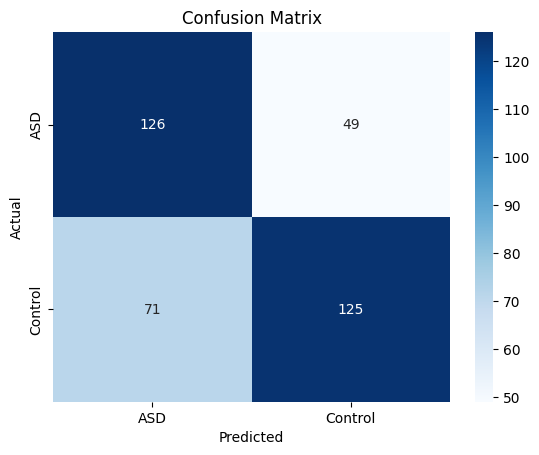

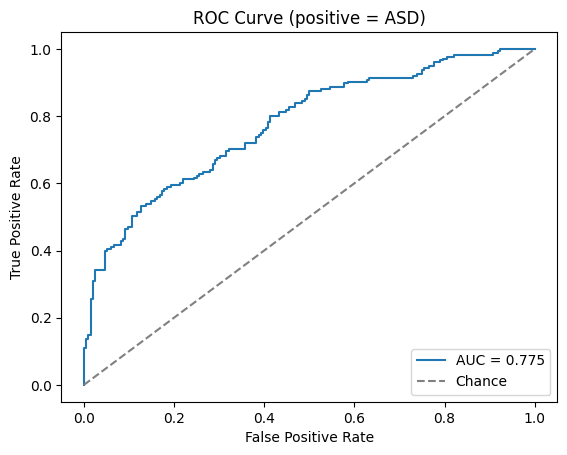

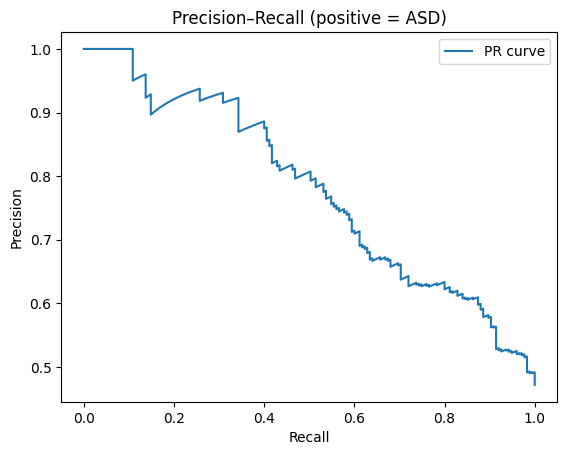

{'accuracy': 0.6765498652291105, 'f1_weighted': 0.676498165846918}

In [37]:
evaluate_model(Yte, yp, proba, positive_label="ASD",
               label_order=("ASD","Control"))

In [28]:
131+44+73+123

371

In [10]:
# after fitting:
clf = logit.named_steps["clf"]

# classes (order matters for interpreting coef_)
classes = clf.classes_
print("Classes:", classes)

# coefficients and intercept
coef = clf.coef_          # shape: (n_classes, n_features) for multinomial, or (1, n_features) for binary
intercept = clf.intercept_ # shape: (n_classes,) or (1,)

# feature names 
feat_cols_arr = np.array(feat_cols)

# --- Binary case: one coefficient vector (usually the 2nd class in classes_) ---
if coef.shape[0] == 1:
    w = coef[0]
    b = intercept[0]
    coef_df = pd.DataFrame({"feature": feat_cols_arr, "coef": w}).sort_values("coef", ascending=False)
    print("Intercept b:", b)
    print(coef_df.head(20))
    print(coef_df.tail(20))

# --- Multiclass case: one vector per class ---
else:
    # long format: one row per (class, feature)
    rows = []
    for k, cls in enumerate(classes):
        rows.append(pd.DataFrame({
            "class": cls,
            "feature": feat_cols_arr,
            "coef": coef[k]
        }))
    coef_df = pd.concat(rows, ignore_index=True)

    print("Intercepts:", dict(zip(classes, intercept)))
    # top features per class
    for cls in classes:
        tmp = coef_df[coef_df["class"] == cls].sort_values("coef", ascending=False)
        print(f"\nTop 15 for class {cls}:")
        print(tmp.head(15))

# optional: save
coef_df.to_csv("logit_coefficients.csv", index=False)


Classes: ['ASD' 'Control']
Intercept b: -0.08228167614808958
                   feature      coef
5444   fc_roi_030__roi_110  0.134337
1984   fc_roi_011__roi_051  0.130325
1965   fc_roi_011__roi_032  0.127757
15995  fc_roi_112__roi_124  0.126652
6567   fc_roi_037__roi_071  0.126188
2154   fc_roi_012__roi_033  0.124819
7314   fc_roi_041__roi_176  0.124420
18103  fc_roi_140__roi_174  0.122114
6955   fc_roi_039__roi_136  0.121981
3314   fc_roi_018__roi_086  0.121817
6880   fc_roi_039__roi_061  0.119719
18689  fc_roi_151__roi_166  0.119206
3346   fc_roi_018__roi_118  0.117663
660    fc_roi_004__roi_071  0.116076
6620   fc_roi_037__roi_124  0.114536
9510   fc_roi_056__roi_107  0.114394
18908  fc_roi_155__roi_199  0.114191
15468  fc_roi_106__roi_140  0.113237
10551  fc_roi_063__roi_168  0.112910
4945   fc_roi_027__roi_124  0.112878
                   feature      coef
5019   fc_roi_027__roi_198 -0.111404
8843   fc_roi_051__roi_170 -0.111654
9673   fc_roi_057__roi_127 -0.112089
3271   fc_roi_

---
(iii) SVM
---


cross validation check for best parameters

In [23]:
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=123)
groups_tr = groups[tr_idx]   # site IDs for the training split

pipe = Pipeline([
    #("scaler", StandardScaler()),    #doesn't change much as Pearson correlations across ROIs are on the same scale
    ("pca", PCA(random_state=123)), #mute for linear
    ("clf", SVC(kernel="rbf", probability=False, random_state=123)) #also done for linear: kernel="linear"
])

Cs = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2,
      1e-1, 0.3, 1, 3, 10, 30, 100, 300, 1e3, 3e3, 1e4, 3e4, 1e5, 3e5, 1e6]  

param_grid = {
    "pca__n_components": [100, 200, 300], # mute for linear 
    "clf__C": Cs, 
    "clf__gamma": ["scale", 1e-3, 3e-3, 1e-2], # mute for linear  
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
    return_train_score=True,
)

grid.fit(Xtr, Ytr, groups=groups_tr)   # <--  groups here

print("Best params:", grid.best_params_)
print("Best CV acc:", round(grid.best_score_, 3))

best = grid.best_estimator_
yp   = best.predict(Xte)
print("Test acc:", round(accuracy_score(Yte, yp), 3))
print(classification_report(Yte, yp, digits=3))

# AUC with decision_function
scores = best.decision_function(Xte)
sign = +1 if best.named_steps["clf"].classes_[1] == "ASD" else -1
scores = sign * scores
print("Test AUC:", round(roc_auc_score((Yte == "ASD").astype(int), scores), 3))


Fitting 10 folds for each of 300 candidates, totalling 3000 fits
Best params: {'clf__C': 10, 'clf__gamma': 0.001, 'pca__n_components': 200}
Best CV acc: 0.663
Test acc: 0.709
              precision    recall  f1-score   support

         ASD      0.701     0.669     0.684       175
     Control      0.716     0.745     0.730       196

    accuracy                          0.709       371
   macro avg      0.708     0.707     0.707       371
weighted avg      0.709     0.709     0.708       371

Test AUC: 0.785


In [19]:
svm = Pipeline([
("clf", SVC(kernel="linear", C=10, gamma="scale", probability=True,  
class_weight=None, random_state=123))
])
svm.fit(Xtr, Ytr)
yp = svm.predict(Xte)
proba = svm.predict_proba(Xte)    

#extract linear features
clf = svm.named_steps["clf"]

# --- coefficients (w) and intercept (b) in the feature space fed to the SVM
w = clf.coef_.ravel()            # shape: (n_features,)
b = float(clf.intercept_[0])     # scalar

print("w shape:", w.shape)
print("b:", b)

# Decision function (hyperplane): w^T x + b = 0


w shape: (19900,)
b: -0.8233016712369375


In [21]:
W = pd.DataFrame({
    "feature": feat_cols,            # your list of column names for X
    "weight":  w
}).sort_values("weight", ascending=False)

W

,feature,weight
1984,fc_roi_011__roi_051,0.030925
5444,fc_roi_030__roi_110,0.028715
15995,fc_roi_112__roi_124,0.028223
6567,fc_roi_037__roi_071,0.028218
14800,fc_roi_099__roi_151,0.026790
...,...,...
16961,fc_roi_123__roi_188,-0.026266
1625,fc_roi_009__roi_071,-0.027616
11570,fc_roi_071__roi_127,-0.029110
8481,fc_roi_049__roi_107,-0.029592


Points on the boundary have value ≈ 0.

In [22]:
# decision values on test set (equal to w^T x + b)
f_te = svm.decision_function(Xte)     # shape: (n_test,)
# Sanity check with explicit dot for a few rows
i = 0
dot_check = float(Xte[i].dot(w) + b)
print(f_te[i], dot_check)             # should be (nearly) identical

0.06987918637045687 0.06987918637052803


Classification Report:
              precision    recall  f1-score   support

         ASD      0.665     0.714     0.689       175
     Control      0.727     0.679     0.702       196

    accuracy                          0.695       371
   macro avg      0.696     0.696     0.695       371
weighted avg      0.698     0.695     0.696       371

Accuracy: 0.695
F1 (weighted): 0.696


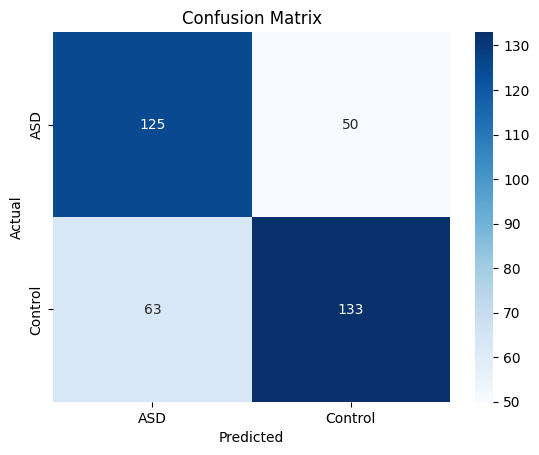

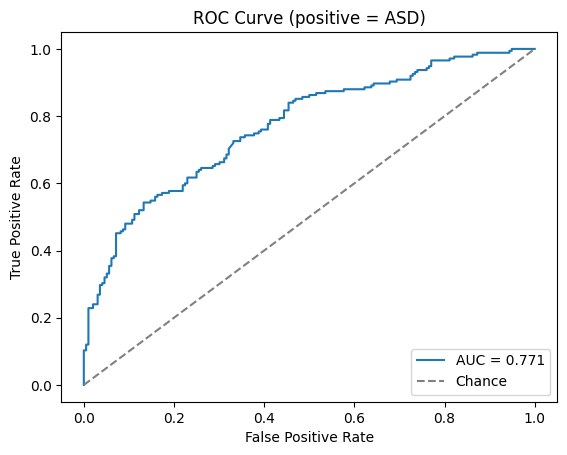

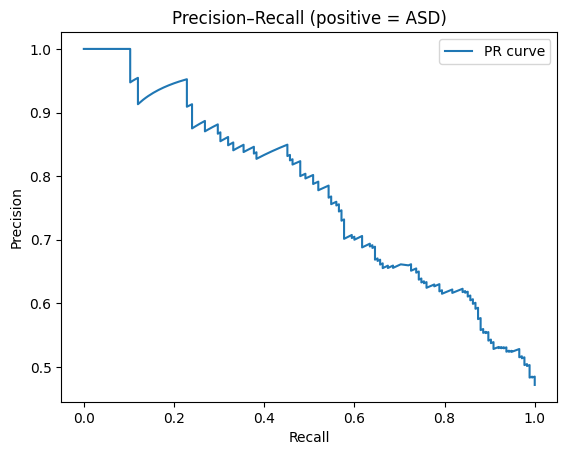

{'accuracy': 0.6954177897574124, 'f1_weighted': 0.6956480357277798}

In [20]:
evaluate_model(Yte, yp, proba, positive_label="ASD",
               label_order=("ASD","Control"))

rbf: (optimal parameters also optained from the earlier cross validation)

In [27]:
svm = Pipeline([
#("scaler", StandardScaler()),
("pca", PCA(n_components=200, random_state=123)),  # pca --> much faster
("clf", SVC(kernel="rbf", C=10, gamma="scale", probability=True,  # C = 3 and gamma = "scale" --> 69.5%
class_weight=None, random_state=123))
])
svm.fit(Xtr, Ytr)
yp = svm.predict(Xte)
proba = svm.predict_proba(Xte)    

Classification Report:
              precision    recall  f1-score   support

         ASD      0.736     0.623     0.675       175
     Control      0.704     0.801     0.749       196

    accuracy                          0.717       371
   macro avg      0.720     0.712     0.712       371
weighted avg      0.719     0.717     0.714       371

Accuracy: 0.717
F1 (weighted): 0.714


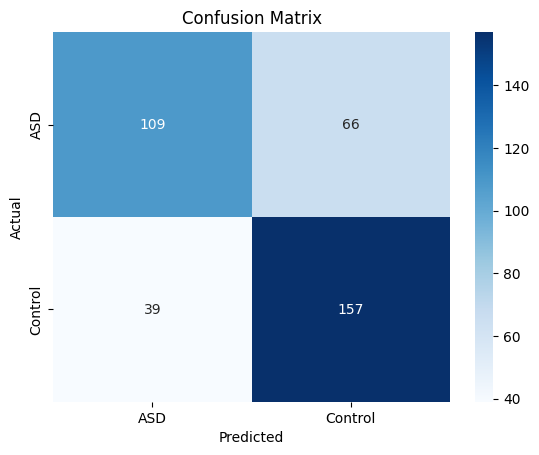

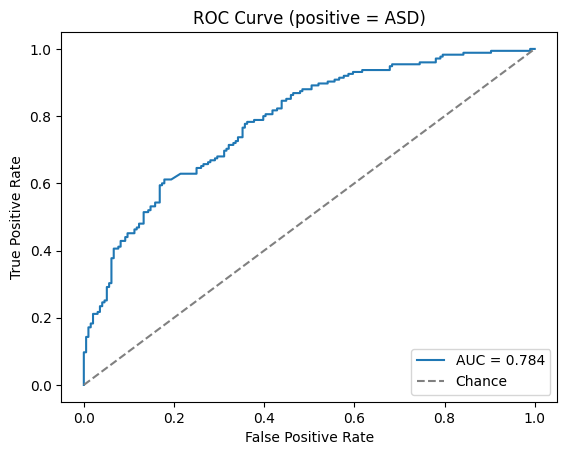

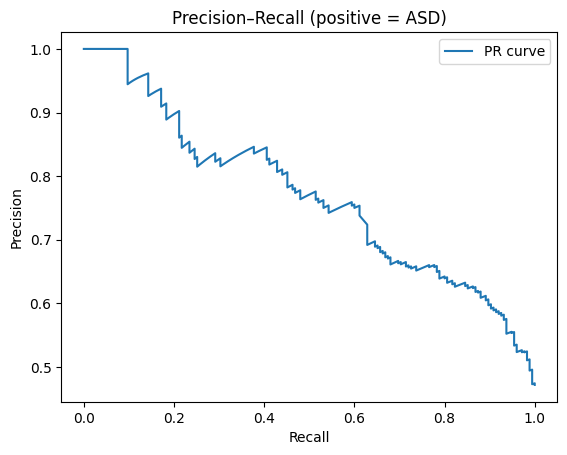

{'accuracy': 0.7169811320754716, 'f1_weighted': 0.7142709164446376}

In [28]:
evaluate_model(Yte, yp, proba, positive_label="ASD",
               label_order=("ASD","Control"))

---
(iv) Classification Trees
---

Best params: {'ccp_alpha': 0.001, 'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 2}
Mean CV AUC: 0.551
Classification Report:
              precision    recall  f1-score   support

         ASD      0.547     0.566     0.556       175
     Control      0.600     0.582     0.591       196

    accuracy                          0.574       371
   macro avg      0.573     0.574     0.573       371
weighted avg      0.575     0.574     0.574       371

Accuracy: 0.574
F1 (weighted): 0.574


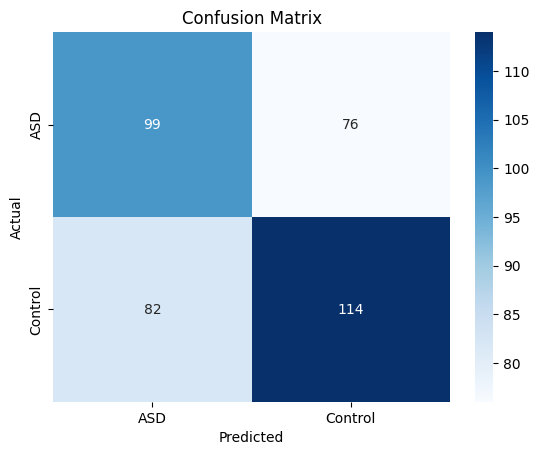

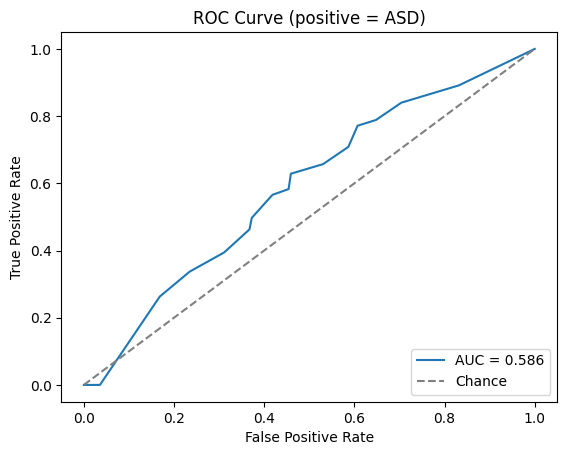

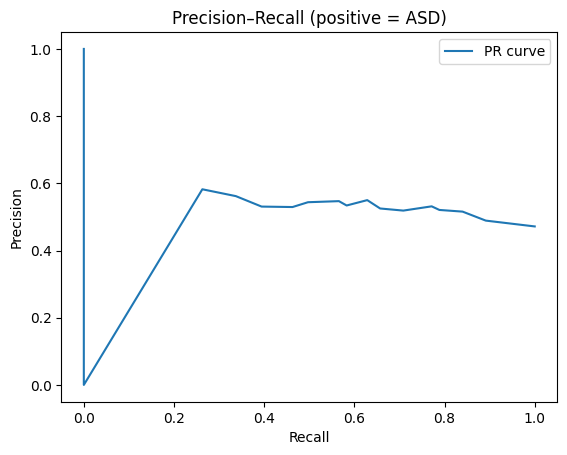

{'accuracy': 0.5741239892183289, 'f1_weighted': 0.5744029148235739}

In [23]:

# ---- group-aware CV on the TRAIN set ----
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=123)

param_grid = {
    "max_depth":         [None, 6, 10, 14, 18, 24, 50, 100, 150],
    "min_samples_leaf":  [1, 5, 10, 20, 40],
    "min_samples_split": [2, 4, 10],
    "ccp_alpha":         [0.0, 1e-4, 5e-4, 1e-3],
}

cart = DecisionTreeClassifier(random_state=123)

grid = GridSearchCV(
    estimator=cart,
    param_grid=param_grid,
    scoring="roc_auc",                    # optimize AUC
    cv=cv,
    n_jobs=-1,
    refit=True,
)

# groups[tr_idx] must be site IDs for the TRAIN rows
grid.fit(Xtr, Ytr.ravel(), groups=groups[tr_idx])

print("Best params:", grid.best_params_)
print("Mean CV AUC:", round(grid.best_score_, 3))

best = grid.best_estimator_

# ---- evaluate on TEST set ----
yp = best.predict(Xte)
proba = best.predict_proba(Xte)[:, list(best.classes_).index("ASD")]

evaluate_model(
    Yte, yp, proba,
    positive_label="ASD",
    label_order=("ASD","Control")
)


In [9]:
# fit
cart = DecisionTreeClassifier(ccp_alpha= 0.001, max_depth=120, min_samples_leaf=20, min_samples_split=2, random_state=123)
cart.fit(Xtr, Ytr)

# predict class labels
yp = cart.predict(Xte)

# predict probabilities 
proba = cart.predict_proba(Xte)

Classification Report:
              precision    recall  f1-score   support

         ASD      0.568     0.571     0.570       175
     Control      0.615     0.612     0.614       196

    accuracy                          0.593       371
   macro avg      0.592     0.592     0.592       371
weighted avg      0.593     0.593     0.593       371

Accuracy: 0.593
F1 (weighted): 0.593


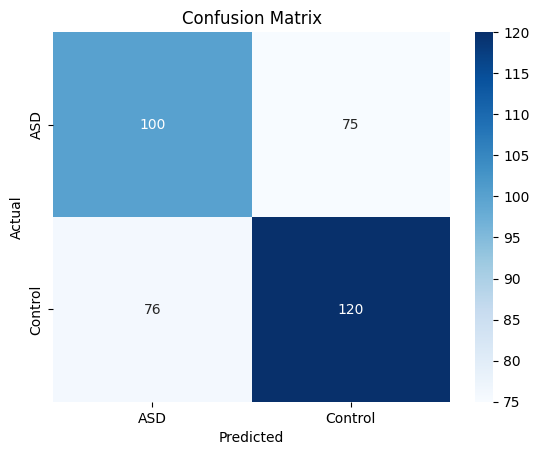

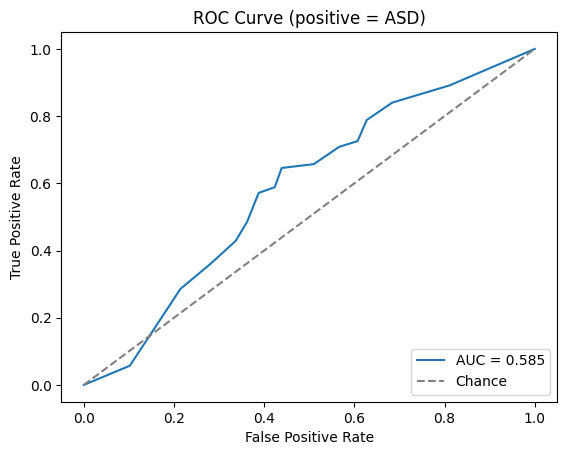

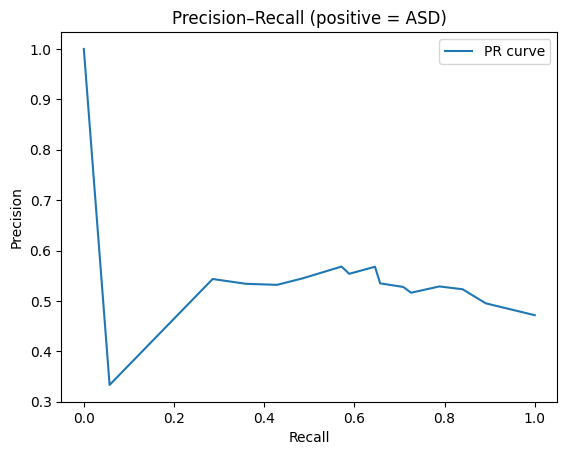

{'accuracy': 0.5929919137466307, 'f1_weighted': 0.5930512266467485}

In [10]:
evaluate_model(Yte, yp, proba, positive_label="ASD", label_order=("ASD","Control"))

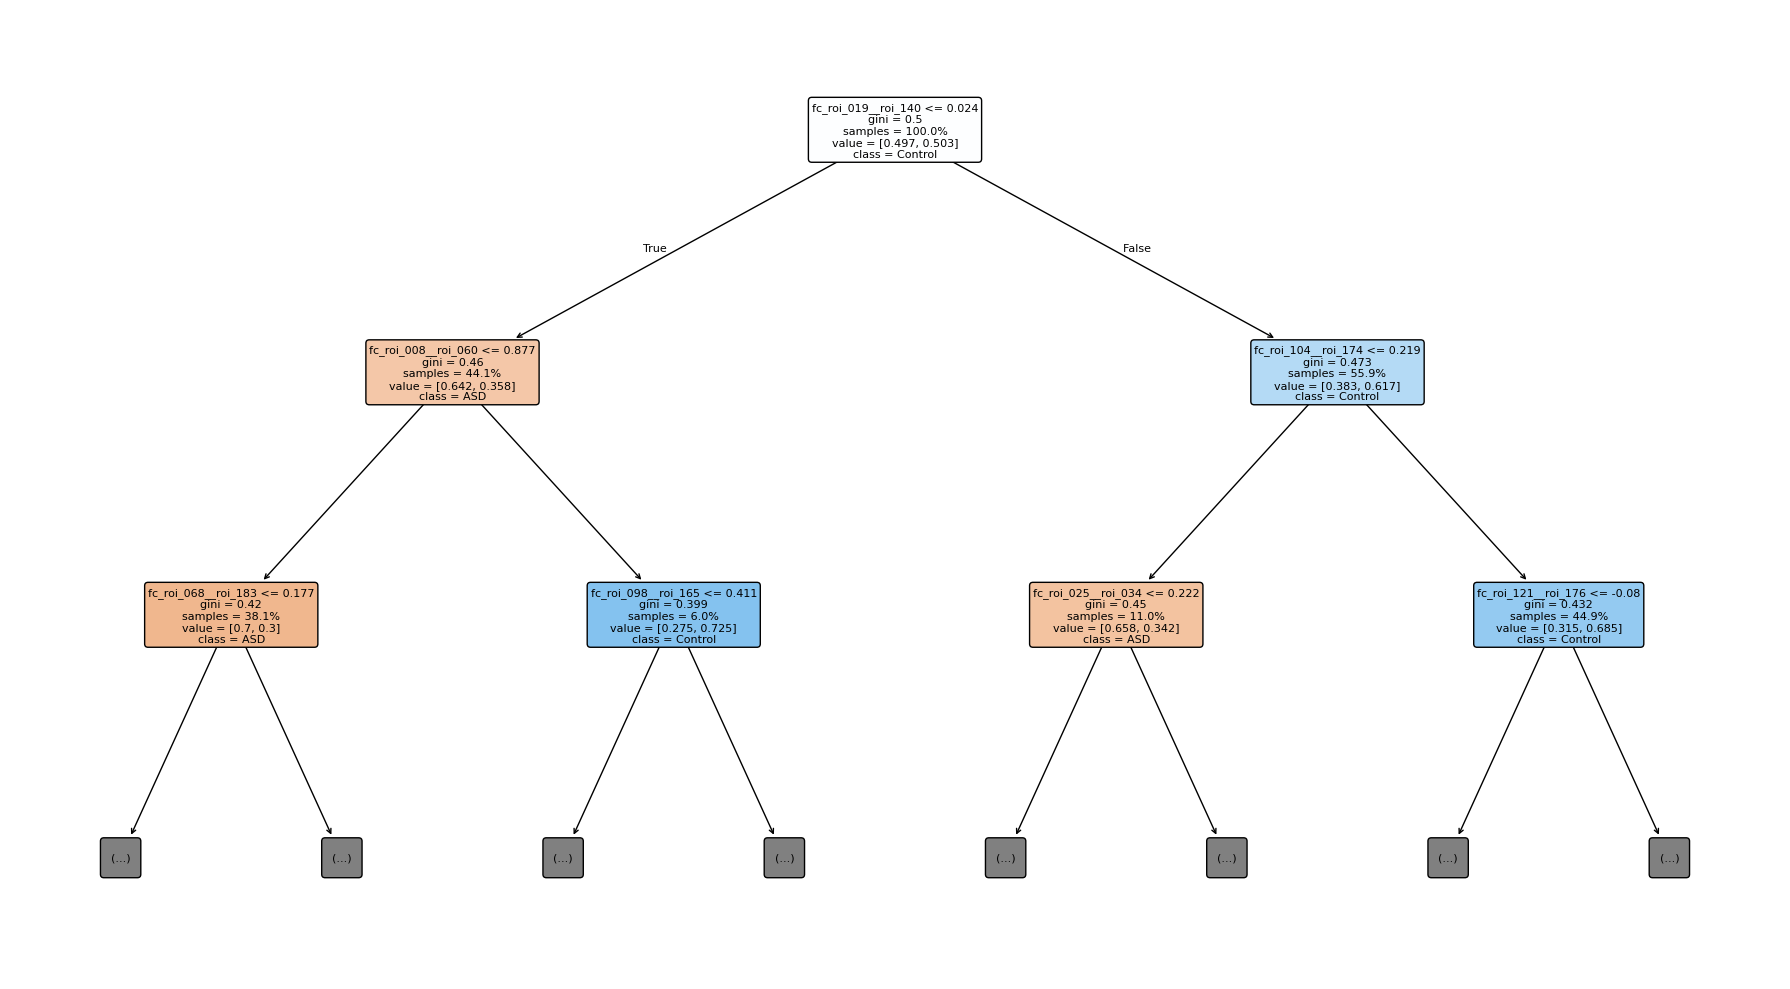

In [11]:
# choose feature names
feat_names = feat_cols if Xtr.shape[1] == len(feat_cols) else None  
class_names = ["ASD", "Control"]

# plot 
plt.figure(figsize=(18, 10))
plot_tree(
    cart,
    feature_names=feat_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    proportion=True,   # show class proportions at nodes
    max_depth=2       # just for the visualization
)
plt.tight_layout()
plt.savefig("tree_top3_matplotlib.png", dpi=200)
plt.show()


----
(v) Random Forest
----


In [12]:

rf_pipe = Pipeline([
    
    ("rf", RandomForestClassifier(
        n_estimators=3000,                                    
        max_depth=50,                                          # stabilizes training. Maximum depth of each tree.
        n_jobs=-1,
        random_state=3,
        class_weight=None                                      # set to 'balanced' if needed
    ))
])

# --- Train ---
rf_pipe.fit(Xtr, Ytr)
yp = rf_pipe.predict(Xte)

proba = rf_pipe.predict_proba(Xte)

Classification Report:
              precision    recall  f1-score   support

         ASD      0.662     0.749     0.702       175
     Control      0.746     0.658     0.699       196

    accuracy                          0.701       371
   macro avg      0.704     0.703     0.701       371
weighted avg      0.706     0.701     0.701       371

Accuracy: 0.701
F1 (weighted): 0.701


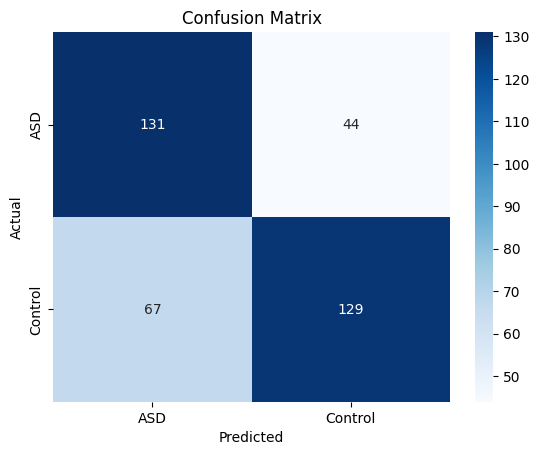

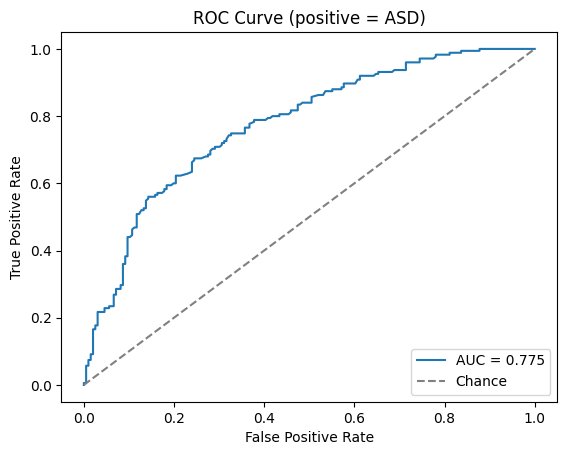

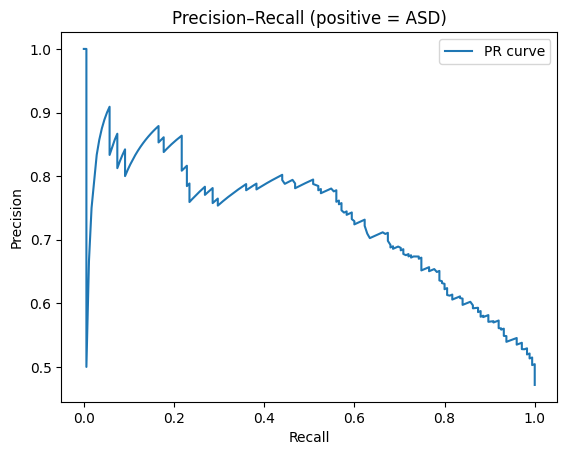

{'accuracy': 0.7008086253369272, 'f1_weighted': 0.7007086318523664}

In [13]:
evaluate_model(Yte, yp, proba, positive_label="ASD",
               label_order=("ASD","Control"))

In [53]:
(153+93+83+154)-1035*0.3

172.5

In [14]:
rf_model = rf_pipe.named_steps["rf"] 

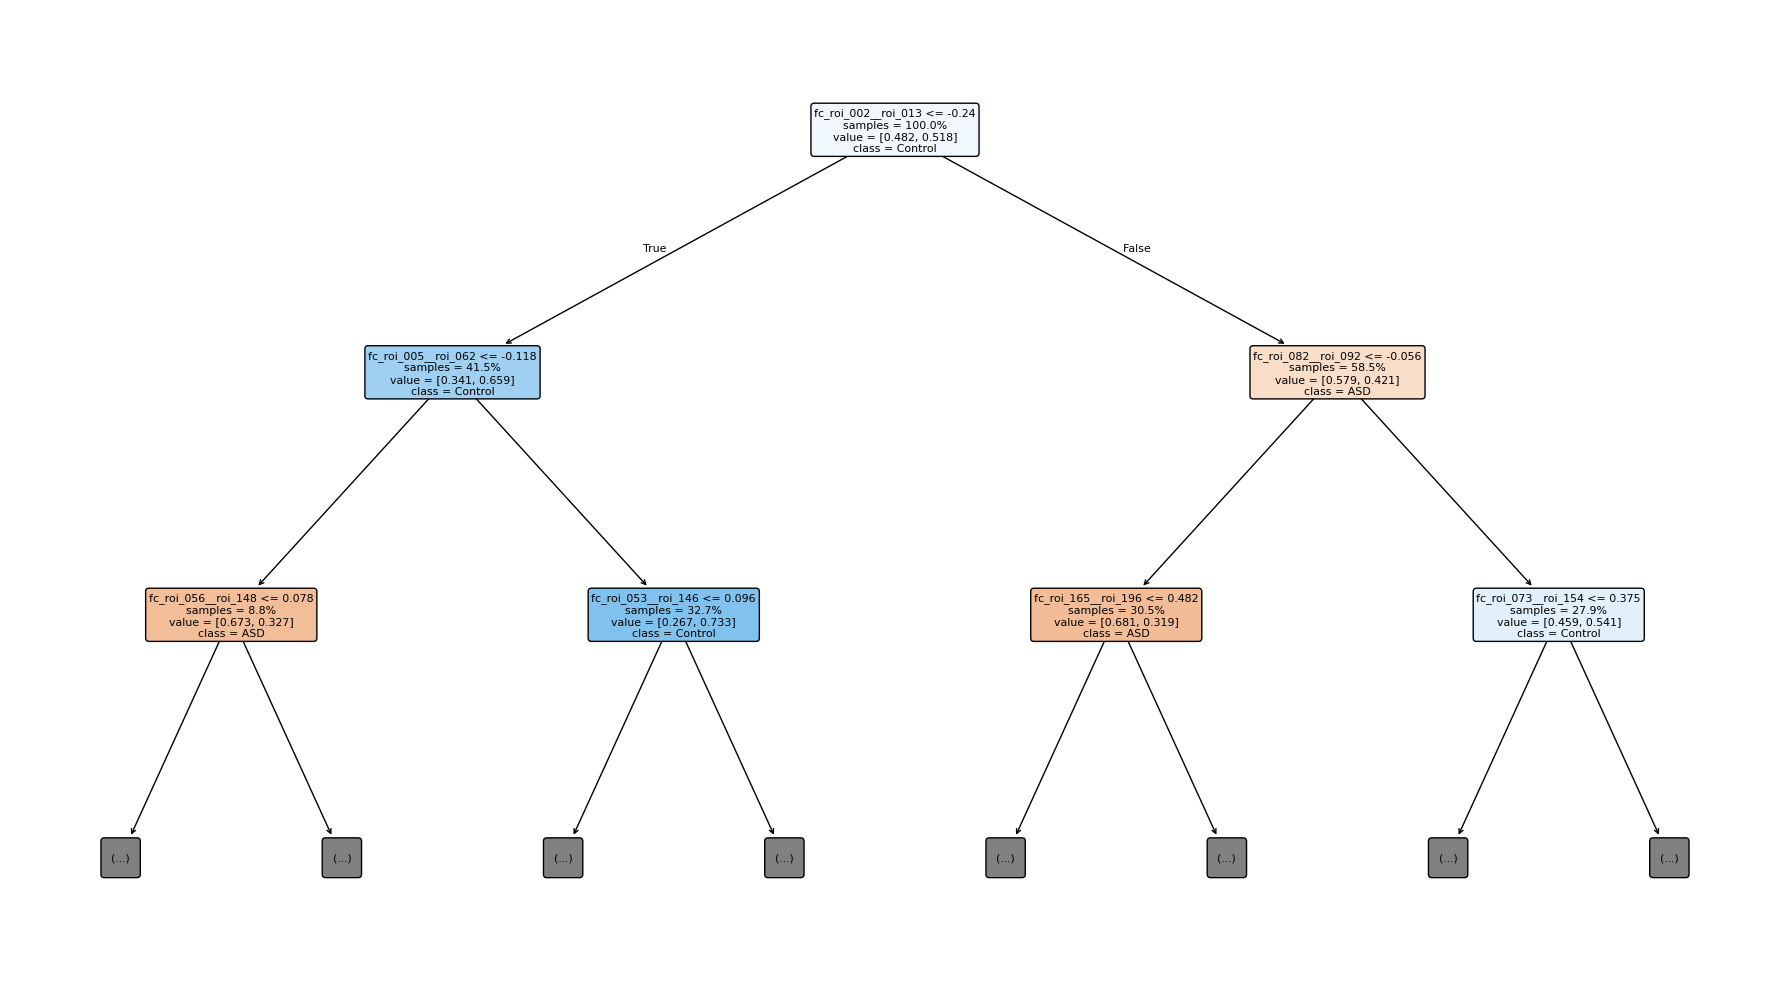

In [15]:

one_tree = rf_model.estimators_[0]

plt.figure(figsize=(18, 10))
plot_tree(
    one_tree,
    feature_names=feat_cols,        
    class_names=["ASD", "Control"], 
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    max_depth=2                    # show only top levels (readable)
)
plt.tight_layout()
plt.savefig("rf_tree0.png", dpi=200)
plt.show()


feature importance extraction  ~ 10 h run time !!

In [16]:
# 1) Fast (built-in) importance
#    = mean decrease in impurity (MDI)
# -----------------------------
mdi = rf_model.feature_importances_  # shape (p,)

# If you have feature names:
# feat_cols = list_of_feature_names  # e.g. from your DataFrame columns
feat_cols = np.array(feat_cols)

mdi_df = pd.DataFrame({
    "feature": feat_cols,
    "importance_mdi": mdi
}).sort_values("importance_mdi", ascending=False)

print(mdi_df.head(20))        # top-20
print(mdi_df.tail(20))        # bottom-20

# Optional: save
mdi_df.to_csv("rf_feature_importance_mdi.csv", index=False)

# -----------------------------
# 2) More trustworthy importance
#    = Permutation importance (drop-in-performance)
#    (handles scaling/units; still tricky with correlated features but less biased than MDI)
# -----------------------------
perm = permutation_importance(
    estimator=rf_pipe,        # pipeline works fine
    X=Xte,
    y=Yte,
    scoring="accuracy",       # or "roc_auc" if you pass probabilities/scores appropriately
    n_repeats=10,
    random_state=123,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": feat_cols,
    "importance_perm_mean": perm.importances_mean,
    "importance_perm_std": perm.importances_std
}).sort_values("importance_perm_mean", ascending=False)

print(perm_df.head(20))
perm_df.to_csv("rf_feature_importance_permutation.csv", index=False)

# -----------------------------
# 3) "top & bottom" table (like SVM)
# -----------------------------
top = perm_df.head(5)
bottom = perm_df.tail(3)

table_df = pd.concat([top, pd.DataFrame([{"feature":"...", "importance_perm_mean":np.nan, "importance_perm_std":np.nan}]), bottom],
                     ignore_index=True)
print(table_df)


                   feature  importance_mdi
3549   fc_roi_019__roi_140        0.001386
3733   fc_roi_020__roi_144        0.000884
18103  fc_roi_140__roi_174        0.000752
3797   fc_roi_021__roi_029        0.000738
3823   fc_roi_021__roi_055        0.000641
3297   fc_roi_018__roi_069        0.000586
9370   fc_roi_055__roi_111        0.000585
4086   fc_roi_022__roi_140        0.000570
2011   fc_roi_011__roi_078        0.000547
9836   fc_roi_058__roi_148        0.000543
9024   fc_roi_053__roi_056        0.000534
5229   fc_roi_029__roi_065        0.000528
11180  fc_roi_068__roi_127        0.000527
14851  fc_roi_100__roi_102        0.000523
18120  fc_roi_140__roi_191        0.000517
12936  fc_roi_082__roi_140        0.000513
16739  fc_roi_120__roi_200        0.000489
8292   fc_roi_048__roi_069        0.000487
98     fc_roi_001__roi_100        0.000479
17704  fc_roi_134__roi_150        0.000478
                   feature  importance_mdi
424    fc_roi_003__roi_031        0.000002
83     fc_r

---
(vi) Gradient Boosting
---

In [15]:
# Fit
gb = GradientBoostingClassifier(
    n_estimators=3000, 
    learning_rate=0.05,
    max_depth=3,        
    subsample=1, 
    random_state=123
)
gb.fit(Xtr, Ytr)     

# Predict class labels
yp = gb.predict(Xte)

# "proba" for  evaluate_model: probability of the positive label ("ASD")
proba = gb.predict_proba(Xte)

Classification Report:
              precision    recall  f1-score   support

         ASD      0.667     0.743     0.703       175
     Control      0.744     0.668     0.704       196

    accuracy                          0.704       371
   macro avg      0.705     0.706     0.704       371
weighted avg      0.708     0.704     0.704       371

Accuracy: 0.704
F1 (weighted): 0.704


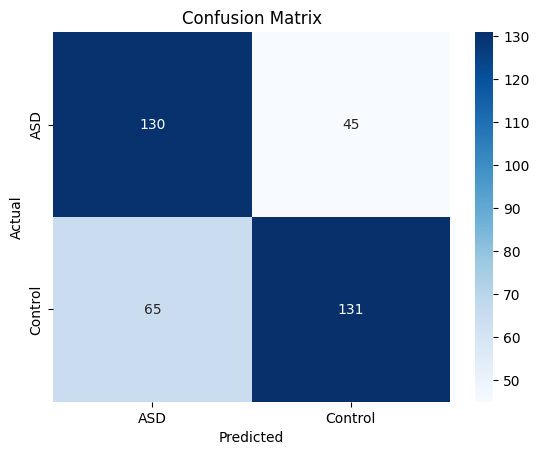

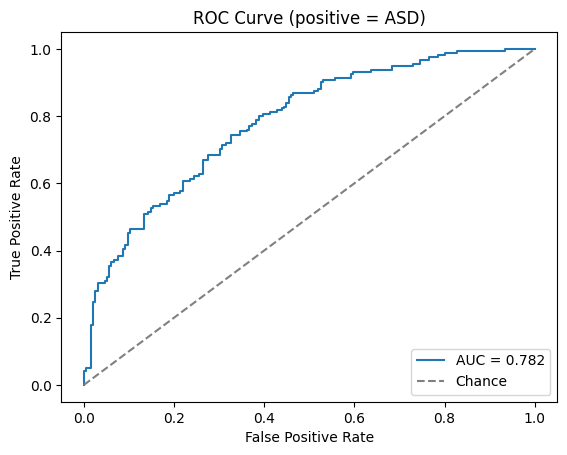

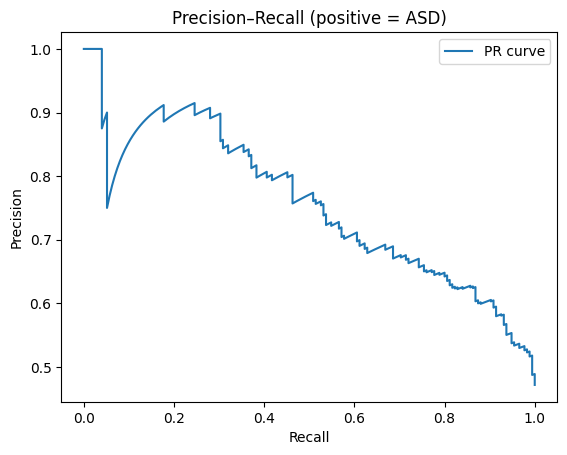

{'accuracy': 0.7035040431266847, 'f1_weighted': 0.7035471259451783}

In [16]:
# Evaluate
evaluate_model(Yte, yp, proba, positive_label="ASD", label_order=("ASD","Control"))

---
(vii) k-Nearest Neighbours (KNN)
---

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Best params: {'knn__n_neighbors': 5, 'knn__weights': 'uniform'} CV acc: 0.557
Classification Report:
              precision    recall  f1-score   support

         ASD      0.713     0.383     0.498       175
     Control      0.610     0.862     0.715       196

    accuracy                          0.636       371
   macro avg      0.661     0.623     0.606       371
weighted avg      0.659     0.636     0.612       371

Accuracy: 0.636
F1 (weighted): 0.612


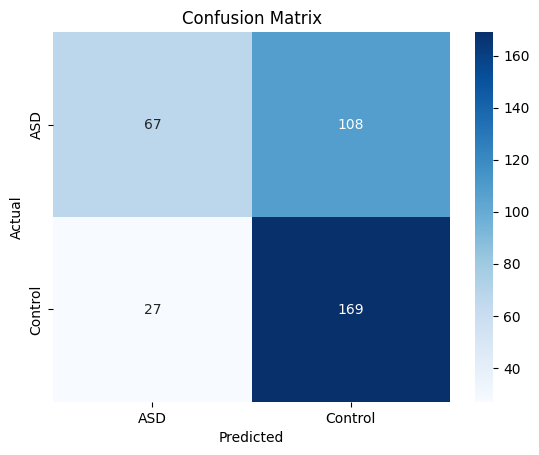

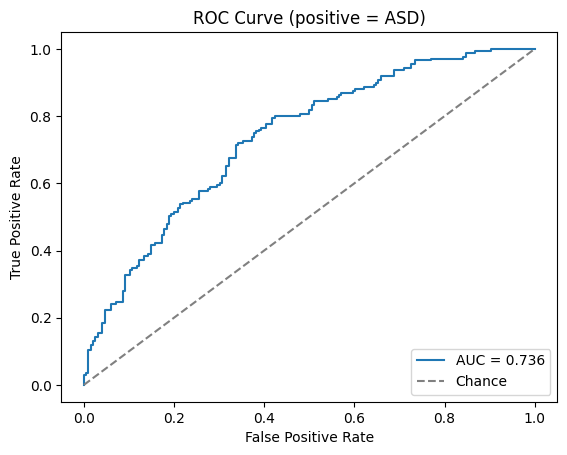

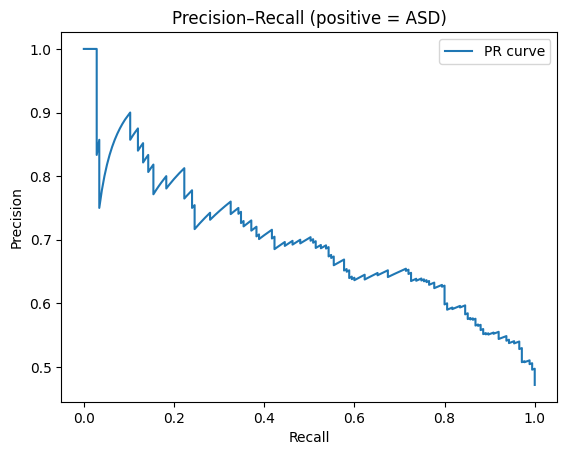

{'accuracy': 0.6361185983827493, 'f1_weighted': 0.6124903444930653}

In [38]:
# cross validation
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors":  [5, 11, 15, 21, 31, 60],
    "knn__weights":      ["uniform", "distance"]
}

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=123)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(Xtr, Ytr, groups=groups[tr_idx])
print("Best params:", grid.best_params_, "CV acc:", round(grid.best_score_, 3))

best_knn = grid.best_estimator_
yp_best  = best_knn.predict(Xte)

# ROC-AUC (binary)
proba_best = best_knn.predict_proba(Xte)[:, list(best_knn.classes_).index("ASD")]

evaluate_model(
    Yte, yp, proba,
    positive_label="ASD",
    label_order=("ASD","Control")
)


In [33]:

knn_pipe = Pipeline([
    
    ("knn", KNeighborsClassifier(n_neighbors=31, weights="distance")) 
])

# ----------  Train ----------
knn_pipe.fit(Xtr, Ytr)
yp = knn_pipe.predict(Xte)

proba = knn_pipe.predict_proba(Xte)#[:, list(knn_pipe.classes_).index("ASD")]


Classification Report:
              precision    recall  f1-score   support

         ASD      0.713     0.383     0.498       175
     Control      0.610     0.862     0.715       196

    accuracy                          0.636       371
   macro avg      0.661     0.623     0.606       371
weighted avg      0.659     0.636     0.612       371

Accuracy: 0.636
F1 (weighted): 0.612


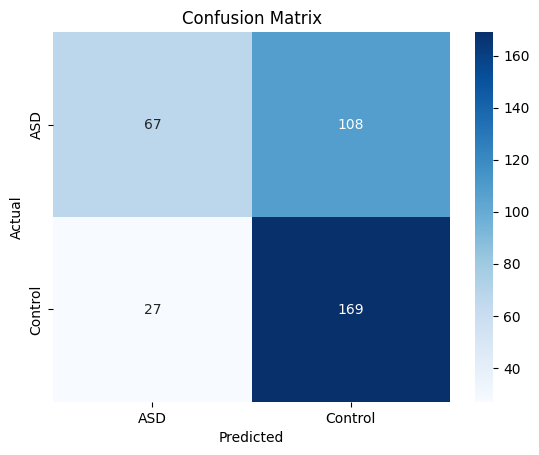

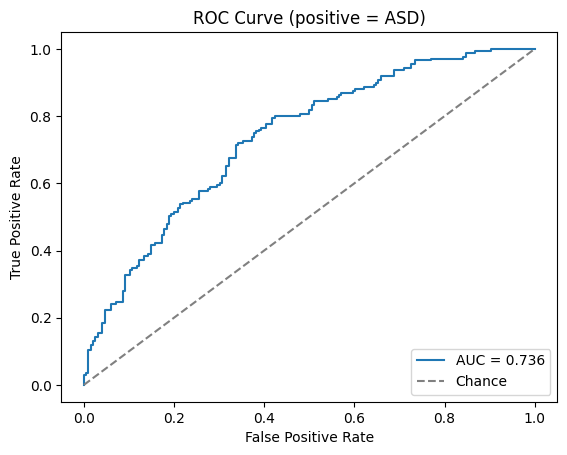

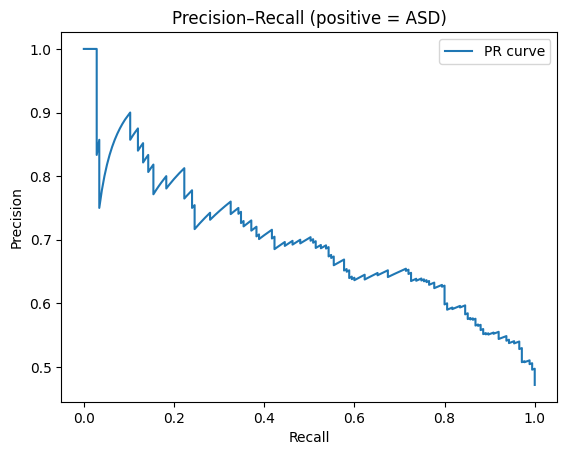

{'accuracy': 0.6361185983827493, 'f1_weighted': 0.6124903444930653}

In [34]:
# Evaluate
evaluate_model(Yte, yp, proba, positive_label="ASD", label_order=("ASD","Control"))